# 01 — Análise Exploratória: Alfabetização Infantil no Brasil

**Tech Challenge Fase 3** — Predição e Inteligência Analítica para Alfabetização no Brasil

Este notebook explora a camada **Gold** reconstruída localmente a partir dos dados brutos do
INEP utilizados na Fase 2 (`Luodev/1IAST-Fase2`), com o objetivo de:

- Entender o comportamento da taxa de alfabetização municipal (2023-2024);
- Avaliar distribuições, padrões regionais e correlações;
- Formular as hipóteses analíticas que orientam a modelagem (notebook `02_modelagem.ipynb`);
- Documentar o risco de *data leakage* identificado nas colunas derivadas da própria métrica-alvo.

> A camada Gold desta Fase 3 foi **reconstruída localmente em pandas** (`src/etl/bronze.py`,
> `silver.py`, `gold.py`), replicando fielmente a lógica dos jobs PySpark/Glue da Fase 2, pois
> não há acesso à conta AWS Learner Lab original. Os 5 CSVs brutos do INEP foram baixados
> diretamente do repositório da Fase 2 (`dados/`).


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.etl.paths import GOLD_DIR, SILVER_DIR, DATA_DIR

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Fontes de dados (camada Bronze/Silver)

Cinco datasets reais do INEP (via Base dos Dados), processados pela pipeline Bronze → Silver → Gold.

In [2]:
raw_sizes = {
    "indicador_municipio (SAEB/ANA por município)": "23.995 linhas",
    "indicador_uf (SAEB/ANA por UF)": "145 linhas",
    "meta_alfabetizacao_brasil (metas nacionais PNA)": "3 linhas",
    "meta_alfabetizacao_uf (metas estaduais PNA)": "54 linhas",
    "meta_alfabetizacao_municipio (metas municipais PNA)": "10.704 linhas",
}
for k, v in raw_sizes.items():
    print(f"{k:55s} -> {v}")


indicador_municipio (SAEB/ANA por município)            -> 23.995 linhas
indicador_uf (SAEB/ANA por UF)                          -> 145 linhas
meta_alfabetizacao_brasil (metas nacionais PNA)         -> 3 linhas
meta_alfabetizacao_uf (metas estaduais PNA)             -> 54 linhas
meta_alfabetizacao_municipio (metas municipais PNA)     -> 10.704 linhas


## 2. Camada Gold — visão `alfabetizacao_por_municipio`

Base da modelagem: taxa observada x meta municipal 2025 (Compromisso Nacional Criança Alfabetizada).

In [3]:
df_gold = pd.read_parquet(GOLD_DIR / "alfabetizacao_por_municipio.parquet")
print(df_gold.shape)
df_gold.head()


(10896, 13)


,id_municipio,ano,serie,rede,taxa_alfabetizacao,media_portugues,meta_2025,meta_2030,nivel_alfabetizacao,gap_meta_2025,status_meta_2025,_gold_processed_at,_ingestion_date
0,1100031,2023,2,municipal,69.10,767.88,72.53,80.0,3,-3.43,NAO_ATINGIU,20260908_230128,2026-09-08
1,1100072,2023,2,municipal,58.20,747.89,65.31,80.0,2,-7.11,NAO_ATINGIU,20260908_230128,2026-09-08
2,1101609,2023,2,municipal,50.70,745.68,60.25,80.0,2,-9.55,NAO_ATINGIU,20260908_230128,2026-09-08
3,1101807,2023,2,municipal,55.69,752.37,63.63,80.0,2,-7.94,NAO_ATINGIU,20260908_230128,2026-09-08
4,1302900,2023,2,municipal,53.17,731.07,61.93,80.0,2,-8.76,NAO_ATINGIU,20260908_230128,2026-09-08


In [4]:
df_gold.info()


<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_municipio         10896 non-null  string 
 1   ano                  10896 non-null  Int64  
 2   serie                10896 non-null  Int64  
 3   rede                 10896 non-null  str    
 4   taxa_alfabetizacao   10896 non-null  float64
 5   media_portugues      10896 non-null  float64
 6   meta_2025            10654 non-null  float64
 7   meta_2030            10654 non-null  float64
 8   nivel_alfabetizacao  10584 non-null  string 
 9   gap_meta_2025        10654 non-null  float64
 10  status_meta_2025     10654 non-null  str    
 11  _gold_processed_at   10896 non-null  str    
 12  _ingestion_date      10896 non-null  str    
dtypes: Int64(2), float64(5), str(4), string(2)
memory usage: 1.6 MB


In [5]:
print("Valores nulos por coluna:")
print(df_gold.isna().sum())
print()
print("Distribuição por ano:")
print(df_gold["ano"].value_counts())


Valores nulos por coluna:
id_municipio             0
ano                      0
serie                    0
rede                     0
taxa_alfabetizacao       0
media_portugues          0
meta_2025              242
meta_2030              242
nivel_alfabetizacao    312
gap_meta_2025          242
status_meta_2025       242
_gold_processed_at       0
_ingestion_date          0
dtype: int64

Distribuição por ano:
ano
2023    5448
2024    5448
Name: count, dtype: Int64


### 2.1 Distribuição da taxa de alfabetização

A taxa de alfabetização municipal (rede municipal, série 2) varia amplamente entre municípios,
com uma cauda inferior expressiva de municípios com taxas muito baixas (< 20%).

C:\Users\Bruno_Reis\AppData\Local\Temp\ipykernel_39436\2079536734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gold, x="ano", y="taxa_alfabetizacao", ax=axes[1], palette="Blues")


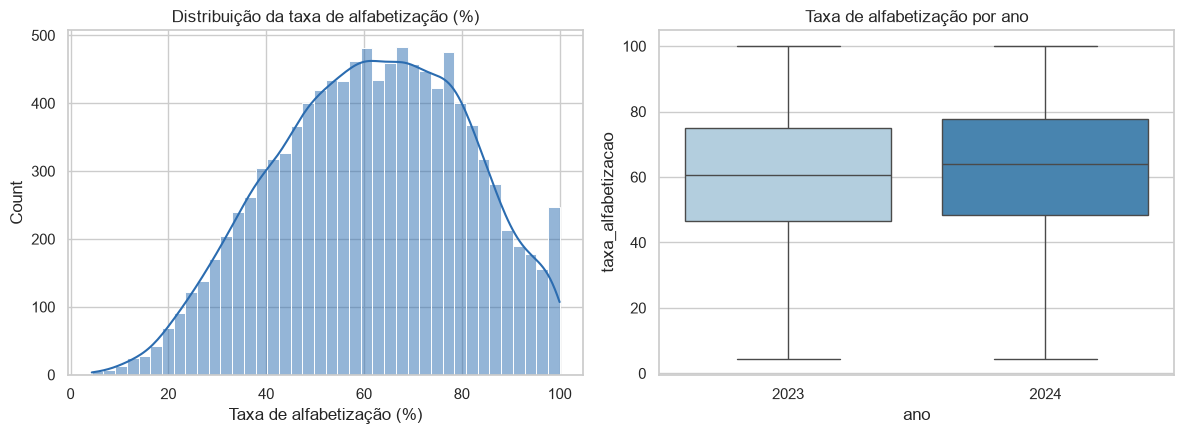

count    10896.000000
mean        61.539116
std         19.623296
min          4.350000
25%         47.365000
50%         62.165000
75%         76.592500
max        100.000000
Name: taxa_alfabetizacao, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_gold["taxa_alfabetizacao"], bins=40, kde=True, ax=axes[0], color="#2b6cb0")
axes[0].set_title("Distribuição da taxa de alfabetização (%)")
axes[0].set_xlabel("Taxa de alfabetização (%)")

sns.boxplot(data=df_gold, x="ano", y="taxa_alfabetizacao", ax=axes[1], palette="Blues")
axes[1].set_title("Taxa de alfabetização por ano")
plt.tight_layout()
plt.savefig("../images/eda_distribuicao_taxa.png", dpi=150)
plt.show()

print(df_gold["taxa_alfabetizacao"].describe())


### 2.2 Status em relação à meta 2025

O rótulo-alvo do problema (`status_meta_2025`) mostra um desbalanceamento moderado: a maioria dos
municípios ainda **não atinge** sua própria meta municipal 2025 do PNA.

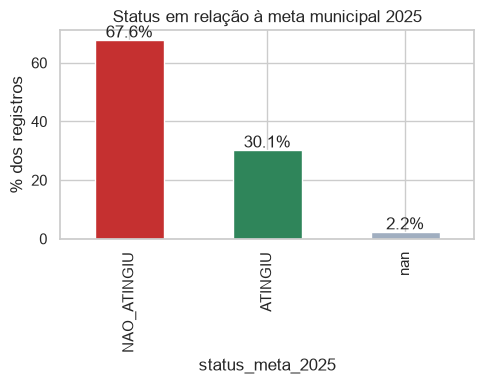

In [7]:
status_counts = df_gold["status_meta_2025"].value_counts(dropna=False, normalize=True) * 100
ax = status_counts.plot(kind="bar", color=["#c53030", "#2f855a", "#a0aec0"], figsize=(5, 4))
ax.set_ylabel("% dos registros")
ax.set_title("Status em relação à meta municipal 2025")
for i, v in enumerate(status_counts):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("../images/eda_status_meta.png", dpi=150)
plt.show()


## 3. Padrões regionais

Unindo com o lookup territorial IBGE (UF/Região) para investigar desigualdades regionais —
diretamente relevante para a pergunta de negócio *"quais regiões possuem padrões semelhantes?"*.

C:\Users\Bruno_Reis\AppData\Local\Temp\ipykernel_39436\3817807715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gold, x="regiao", y="taxa_alfabetizacao", order=ordem_regiao, palette="Blues", ax=ax)


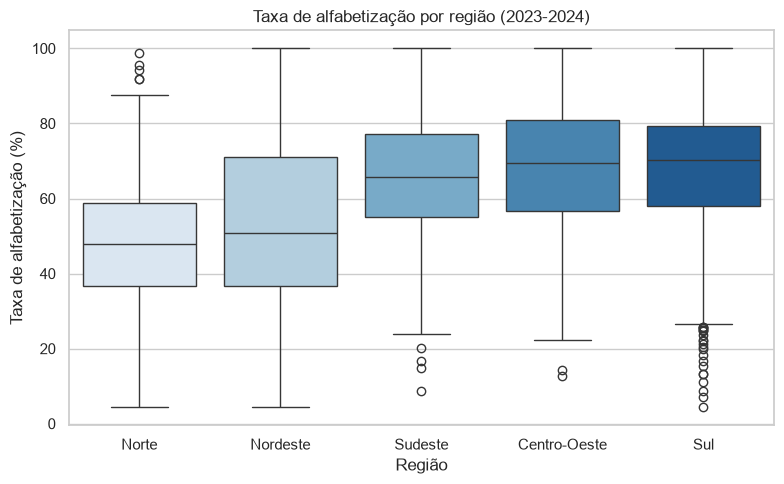

,mean,50%,std
regiao,,,
Centro-Oeste,68.435113,69.440,16.955272
Nordeste,54.680753,50.905,22.838561
Norte,47.663550,47.795,16.200224
Sudeste,66.143422,65.780,15.028560
Sul,68.021212,70.210,15.741622


In [8]:
from src.etl.uf_lookup import IBGE_UF, REGIAO_UF

df_gold = df_gold.copy()
df_gold["sigla_uf"] = df_gold["id_municipio"].str[:2].map(IBGE_UF)
df_gold["regiao"] = df_gold["sigla_uf"].map(REGIAO_UF)

ordem_regiao = df_gold.groupby("regiao")["taxa_alfabetizacao"].median().sort_values().index

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_gold, x="regiao", y="taxa_alfabetizacao", order=ordem_regiao, palette="Blues", ax=ax)
ax.set_title("Taxa de alfabetização por região (2023-2024)")
ax.set_xlabel("Região")
ax.set_ylabel("Taxa de alfabetização (%)")
plt.tight_layout()
plt.savefig("../images/eda_taxa_por_regiao.png", dpi=150)
plt.show()

df_gold.groupby("regiao")["taxa_alfabetizacao"].describe()[["mean", "50%", "std"]]


In [9]:
top_bottom = (
    df_gold[df_gold["ano"] == 2024]
    .groupby("sigla_uf")["taxa_alfabetizacao"]
    .mean()
    .sort_values()
)
print("5 UFs com menor taxa média (2024):")
print(top_bottom.head(5))
print()
print("5 UFs com maior taxa média (2024):")
print(top_bottom.tail(5))


5 UFs com menor taxa média (2024):
sigla_uf
SE    36.446533
BA    36.598501
RN    41.644759
AC    43.500000
AM    44.798387
Name: taxa_alfabetizacao, dtype: float64

5 UFs com maior taxa média (2024):
sigla_uf
PR    74.084812
MG    75.060482
ES    78.190256
GO    80.253878
CE    90.310380
Name: taxa_alfabetizacao, dtype: float64


## 4. Correlações e risco de *data leakage*

Antes de definir as features do modelo, é essencial verificar quais colunas são
**transformações quase-determinísticas** da própria taxa de alfabetização — usá-las como
preditoras vazaria o alvo (`status_meta_2025` é definido a partir da comparação
`taxa_alfabetizacao >= meta_2025`).

In [10]:
df_ind = pd.read_parquet(SILVER_DIR / "pass" / "indicador_municipio.parquet")
df_ind_mun = df_ind[df_ind["rede"] == "3"]

# nivel_alfabetizacao já vem na própria visão Gold (join feito em src/etl/gold.py)
# -- aqui verificamos se ele é um bucket discreto da própria taxa
df_check = df_gold.dropna(subset=["nivel_alfabetizacao"]).copy()
df_check["nivel_alfabetizacao"] = df_check["nivel_alfabetizacao"].astype(int)

print("Faixa de taxa_alfabetizacao por nivel_alfabetizacao (confirma bucket discreto):")
print(df_check.groupby("nivel_alfabetizacao")["taxa_alfabetizacao"].agg(["min", "max", "count"]))


Faixa de taxa_alfabetizacao por nivel_alfabetizacao (confirma bucket discreto):
                       min     max  count
nivel_alfabetizacao                      
0                     4.35   40.00   1605
1                    40.00   50.00   1429
2                    50.00   91.67   1783
3                    60.00   70.00   1898
4                    70.00   80.00   1810
5                    80.00  100.00   2059


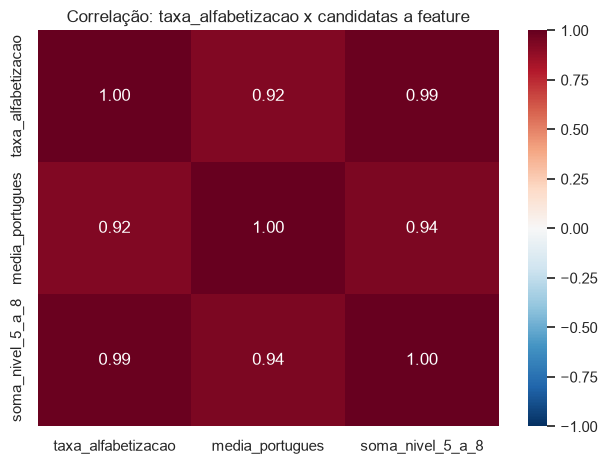

corr(taxa, soma proporcao nivel 5-8) = 0.9855
corr(taxa, media_portugues)          = 0.9235


In [11]:
# proporcao_aluno_nivel_5..8 (SAEB) tem correlação > 0.9 com taxa_alfabetizacao
cols_nivel = [f"proporcao_aluno_nivel_{i}" for i in range(9)]
sub = df_ind_mun.dropna(subset=cols_nivel).copy()
sub["soma_nivel_5_a_8"] = sub[[f"proporcao_aluno_nivel_{i}" for i in range(5, 9)]].sum(axis=1)

corr = sub[["taxa_alfabetizacao", "media_portugues", "soma_nivel_5_a_8"]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlação: taxa_alfabetizacao x candidatas a feature")
plt.tight_layout()
plt.savefig("../images/eda_correlacao_leakage.png", dpi=150)
plt.show()

print(f"corr(taxa, soma proporcao nivel 5-8) = {sub['taxa_alfabetizacao'].corr(sub['soma_nivel_5_a_8']):.4f}")
print(f"corr(taxa, media_portugues)          = {sub['taxa_alfabetizacao'].corr(sub['media_portugues']):.4f}")


**Conclusão (decisão analítica registrada em `src/preprocessing/build_features.py`):**

| Coluna | Motivo de exclusão |
|---|---|
| `taxa_alfabetizacao`, `gap_meta_2025` | Definem o alvo diretamente |
| `nivel_alfabetizacao` | Bucket discreto de `taxa_alfabetizacao` (nível 5 = 100% ATINGIU) |
| `proporcao_aluno_nivel_5..8` | Soma tem correlação de 0,99 com `taxa_alfabetizacao` (mesma medida decomposta) |
| `serie` | Constante (sempre = 2), sem variância |
| `meta_alfabetizacao_2030` | Constante (sempre = 80,0), sem variância |

`media_portugues` foi **mantida**: apesar de correlacionada (~0,93), é uma medida psicométrica
distinta (escala de proficiência, não percentual de aprovação) e evita reconstrução direta do alvo.


## 5. Dataset final de modelagem

Construído em `src/preprocessing/build_features.py`, no grão *município x ano* (rede municipal),
com engenharia de atributos adicional: meta estadual (`meta_uf_2025`) e média estadual
*leave-one-out* da taxa de alfabetização dos municípios pares (`taxa_media_uf_loo`), que captura
efeito regional sem vazar a métrica do próprio município.

In [12]:
df_feat = pd.read_parquet(DATA_DIR / "features" / "dataset_modelagem.parquet")
print(df_feat.shape)
display(df_feat.head())
print()
print("Balanceamento do alvo:")
print(df_feat["alvo_alfabetizado"].value_counts(normalize=True).rename("proporcao"))


(10654, 9)


,id_municipio,ano,sigla_uf,regiao,media_portugues,meta_2025,meta_uf_2025,taxa_media_uf_loo,alvo_alfabetizado
0,1100031,2023,RO,Norte,767.88,72.53,69.5,65.00,0
1,1100072,2023,RO,Norte,747.89,65.31,69.5,65.21,0
2,1101609,2023,RO,Norte,745.68,60.25,69.5,65.36,0
3,1101807,2023,RO,Norte,752.37,63.63,69.5,65.26,0
4,1302900,2023,AM,Norte,731.07,61.93,61.3,46.13,0



Balanceamento do alvo:
alvo_alfabetizado
0    0.691853
1    0.308147
Name: proporcao, dtype: float64


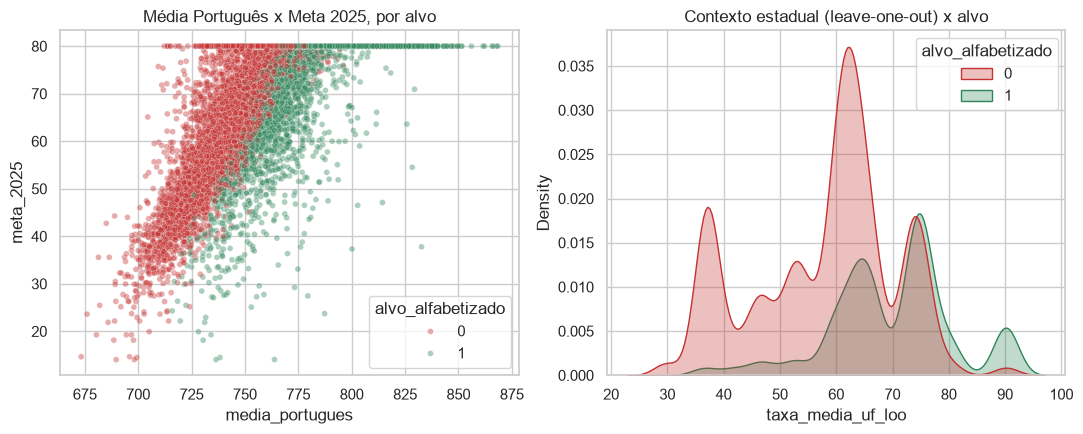

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(
    data=df_feat, x="media_portugues", y="meta_2025", hue="alvo_alfabetizado",
    palette={0: "#c53030", 1: "#2f855a"}, alpha=0.4, s=18, ax=axes[0]
)
axes[0].set_title("Média Português x Meta 2025, por alvo")

sns.kdeplot(
    data=df_feat, x="taxa_media_uf_loo", hue="alvo_alfabetizado",
    palette={0: "#c53030", 1: "#2f855a"}, fill=True, alpha=0.3, ax=axes[1]
)
axes[1].set_title("Contexto estadual (leave-one-out) x alvo")
plt.tight_layout()
plt.savefig("../images/eda_features_vs_alvo.png", dpi=150)
plt.show()


## 6. Hipóteses analíticas para a modelagem

1. **H1** — `media_portugues` é o preditor mais forte disponível sem vazamento (correlação 0,93
   com a taxa, porém medida distinta), portanto deve dominar a importância de features.
2. **H2** — Existe forte heterogeneidade regional (Norte/Nordeste com taxas sistematicamente mais
   baixas), portanto UF/Região devem contribuir mesmo controlando por `media_portugues`.
3. **H3** — Dado que o alvo é definido por um limiar (`taxa >= meta_2025`) e as features
   candidatas têm relação aproximadamente monotônica com a taxa, um modelo **linear**
   (Regressão Logística) é um baseline forte — testado formalmente no notebook de modelagem.
4. **H4** — Modelos de árvore com profundidade livre tendem a **overfitar** o ano de treino
   (2023) e generalizar mal para 2024, dado o pequeno número de features contínuas realmente
   informativas — hipótese testada via *holdout* temporal em `02_modelagem.ipynb`.

Essas hipóteses são retomadas e validadas (ou refutadas) no notebook de modelagem.
